In [16]:
# Parameters

ESTIMATION_DEPTH = 1000

TRAINING_ITERATIONS = 100000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 1

HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 4

In [17]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNCentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- PyTorch is configured to use: {DEVICE} ---")

--- PyTorch is configured to use: cuda ---


In [18]:
from dataclasses import dataclass
from typing import Any


@dataclass
class State:
    apples: np.ndarray[Any, np.dtype[np.int_]]
    agents: np.ndarray[Any, np.dtype[np.int_]]
    def __hash__(self):
        # Convert the numpy arrays to their byte representation, which is hashable
        return hash((self.agents.tobytes(), self.apples.tobytes()))

    def __eq__(self, other):
        # Define how to check for equality between two State objects
        return np.array_equal(self.agents, other.agents) and np.array_equal(self.apples, other.apples)

In [19]:
s_0: State = State(
    apples=np.array(
        [
            [0, 1, 0, 0], 
            [0, 0, 0, 0], 
            [0, 0, 1, 0],
            [0, 0, 0, 0]
            ], dtype=int),
    agents=np.array(
        [
            [1, 0, 0, 0], 
            [0, 0, 0, 0], 
            [0, 0, 0, 0],
            [0, 0, 0, 0]
            ], dtype=int)
)
WIDTH = s_0.apples.shape[1]
HEIGHT = s_0.apples.shape[0]
print(f"Grid size: {WIDTH} x {HEIGHT}")

Grid size: 4 x 4


In [20]:
for action in Action2D:
    # 'action' is an Enum member, e.g., Action2D.LEFT
    print(f"- **Action:** {action.name}")
    print(f"  **Index (idx):** {action.idx}")
    print(f"  **Vector:** {action.vector}")
print(f"number of actions: {len(Action2D)}")
NUM_ACTIONS = len(Action2D)

- **Action:** LEFT
  **Index (idx):** 0
  **Vector:** [ 0 -1]
- **Action:** RIGHT
  **Index (idx):** 1
  **Vector:** [0 1]
- **Action:** STAY
  **Index (idx):** 2
  **Vector:** [0 0]
- **Action:** UP
  **Index (idx):** 3
  **Vector:** [-1  0]
- **Action:** DOWN
  **Index (idx):** 4
  **Vector:** [1 0]
number of actions: 5


### First Get True Value

In [21]:
def simulate_step(s: State, agent_pos: np.ndarray, action_vector: np.ndarray):
    """
    A stateless simulation function.
    Takes the current state and an action, and returns the reward and the next state.
    """
    current_agents = s.agents
    current_apples = s.apples
    # Use the grid shape from the input array
    grid_shape = current_agents.shape
    
    # Calculate the new position
    new_position = np.clip(
        agent_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    # Work on copies of the input state
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    # Move the agent
    next_agents[tuple(new_position)] += 1
    next_agents[tuple(agent_pos)] -= 1
    
    # Check for reward
    reward = 0
    if next_apples[tuple(new_position)] > 0:
        next_apples[tuple(new_position)] -= 1
        reward = 1
        
    return reward, State(next_apples, next_agents)

In [22]:
memoization_cache = {}
def get_true_value_random_policy(s: State, depth: int) -> float:
    """Returns the expected value of [sum from t=0 to depth-1] y^t r_t
    
    Uses a memoization cache where
        -keys: (s_t: State, cur_depth: int)
        -values: V(s_t): float

    Args:
        s_t: _description_
        cur_depth: _description_
        cur_val: _description_

    Returns:
        _description_
    """
    memoization_cache.clear()
    def value(s_t: State, cur_depth: int) -> float:
        if cur_depth == depth:
            return 0.0
        if (s_t, cur_depth) in memoization_cache:
            return memoization_cache[(s_t, cur_depth)]
        
        V_s_t = 0.0
        for action in Action2D:
            agent_pos = np.argwhere(s_t.agents == 1)
            if not agent_pos.shape[0] == 1:
                raise ValueError(f"agent_pos: {agent_pos}")
            agent_pos = agent_pos[0]
            pi_a_t_given_s_t = 1.0 / NUM_ACTIONS
            r_t, s_t_plus_1 = simulate_step(s_t, agent_pos, action.vector)
            V_s_t_plus_1 = value(s_t_plus_1, cur_depth + 1)
            V_s_t += pi_a_t_given_s_t * (r_t + DISCOUNT * V_s_t_plus_1)
            
        memoization_cache[(s_t, cur_depth)] = V_s_t
        return V_s_t
    
    # do V(s_0) manually to create progress bar
    V_s_initial = 0.0
    initial_agent_pos = np.argwhere(s.agents == 1)[0]
    
    # Create the progress bar for the 5 top-level actions
    progress_bar = tqdm(Action2D, desc=f"Calculating True Value (Depth={depth})")
    
    for action in progress_bar:
        pi_a_t_given_s_t = 1.0 / NUM_ACTIONS
        
        # Simulate the first step
        r_0, s_1 = simulate_step(s, initial_agent_pos, action.vector)
        
        # Call the recursive function for the rest of the trajectory, starting at depth 1
        future_value = value(s_1, 1)
        
        action_value = r_0 + DISCOUNT * future_value
        V_s_initial += pi_a_t_given_s_t * action_value
        
    return V_s_initial


In [23]:
max_value_error = (DISCOUNT ** ESTIMATION_DEPTH) / (1 - DISCOUNT)
print(f"Maximum value error due to depth limitation: {max_value_error}")

Maximum value error due to depth limitation: 0.004317124741065783


In [24]:
true_val_s_0 = get_true_value_random_policy(s_0, ESTIMATION_DEPTH)
print(f"True value of state s_0 under random policy: {true_val_s_0}")


Calculating True Value (Depth=1000):   0%|          | 0/5 [00:00<?, ?it/s]

Calculating True Value (Depth=1000): 100%|██████████| 5/5 [00:07<00:00,  1.41s/it]

True value of state s_0 under random policy: 1.6037730741589047


### Now get CNN Centralized Estimate Value

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt

history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNCentralized):
    """Compute and store one-line summary statistics per batch."""
    with torch.no_grad():
        if len(net.batch_states) == 0:
            return
        device = next(net.parameters()).device  # automatically detect whether the net is on cpu or cuda

        states = torch.tensor(np.stack(net.batch_states), dtype=torch.float32, device=device)
        next_states = torch.tensor(np.stack(net.batch_new_states), dtype=torch.float32, device=device)
        rewards = torch.tensor(net.batch_rewards, dtype=torch.float32, device=device)
        preds = net.forward(states).squeeze(1)
        targets = rewards + net.trainer.discount * net.forward(next_states).squeeze(1)
        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
    

def train_value_cnn(cnn: ValueCNNCentralized, s_t: State, r_t: float, s_t_plus_1: State):
    raw_state_t = {"apples": s_t.apples, "agents": s_t.agents}
    raw_state_t_plus_1 = {"apples": s_t_plus_1.apples, "agents": s_t_plus_1.agents}
    processed_state_t = cnn.raw_state_to_nn_input(raw_state_t)
    processed_state_t_plus_1 = cnn.raw_state_to_nn_input(raw_state_t_plus_1)
    cnn.add_experience(processed_state_t, processed_state_t_plus_1, r_t)
    
    if len(cnn.batch_states) >= BATCH_SIZE:
        log_batch_stats(cnn)
        loss = cnn.train_batch()
            
   
    

In [26]:
value_CNN_centralized = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS)

EPISODE_LENGTH = 200
NUM_EPISODES = 500
progress_bar = tqdm(range(NUM_EPISODES), desc="Training Episodes")
for episode in progress_bar:
    s_t = s_0
    for t in range(EPISODE_LENGTH):
        agents = s_t.agents
        c = np.argwhere(agents == 1)
        assert c.shape[0] == 1, "There should be exactly one agent."
        # use random policy
        action = Action2D.get_random_action()
        r_t, s_t_plus_1 = simulate_step(s_t, c[0], action.vector)
        train_value_cnn(value_CNN_centralized, s_t, r_t, s_t_plus_1)
        s_t = s_t_plus_1
        # don't spawn and despawn for now    

Training Episodes:   0%|          | 0/500 [00:00<?, ?it/s]

Training Episodes: 100%|██████████| 500/500 [16:54<00:00,  2.03s/it]


In [27]:
raw_state = {"apples": s_0.apples, "agents": s_0.agents}
predicted_value = value_CNN_centralized.get_model_reward_prediction_from_raw(raw_state)
print(f"Predicted value of state s_0 by trained CNN: {predicted_value.item()}")

Predicted value of state s_0 by trained CNN: 1.7510466575622559


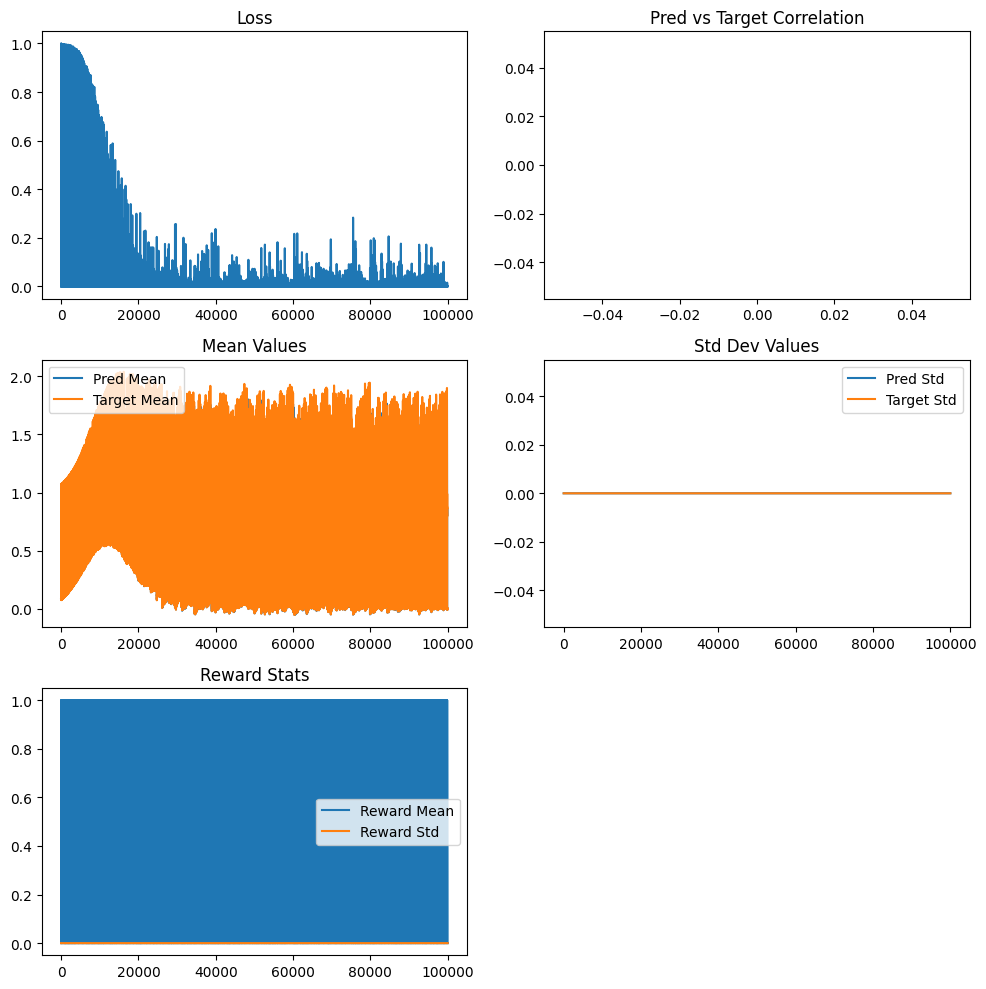

In [28]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(value_CNN_centralized)
